# Taller 8: Redes Neuronales Convolucionales

### Sebastián Palma

In [38]:
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import os
import cv2
import json
from tensorflow import keras
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from sklearn.metrics import f1_score
from tensorflow.keras.models import load_model
from sklearn.metrics import f1_score, precision_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

## 1. Diseño y Construcción de una Red Convolucional Propia

### 1.1 Descarga y Preparación del Dataset

In [18]:
from kaggle.api.kaggle_api_extended import KaggleApi

with open('./kaggle.json') as f:
    kaggle_credentials = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle_credentials['username']
os.environ['KAGGLE_KEY'] = kaggle_credentials['key']

api = KaggleApi()
api.authenticate()
api.dataset_download_files('zulkarnainsaurav/four-genre-movie-poster-images', path='data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/zulkarnainsaurav/four-genre-movie-poster-images


### 1.2 Exploración de Imágenes

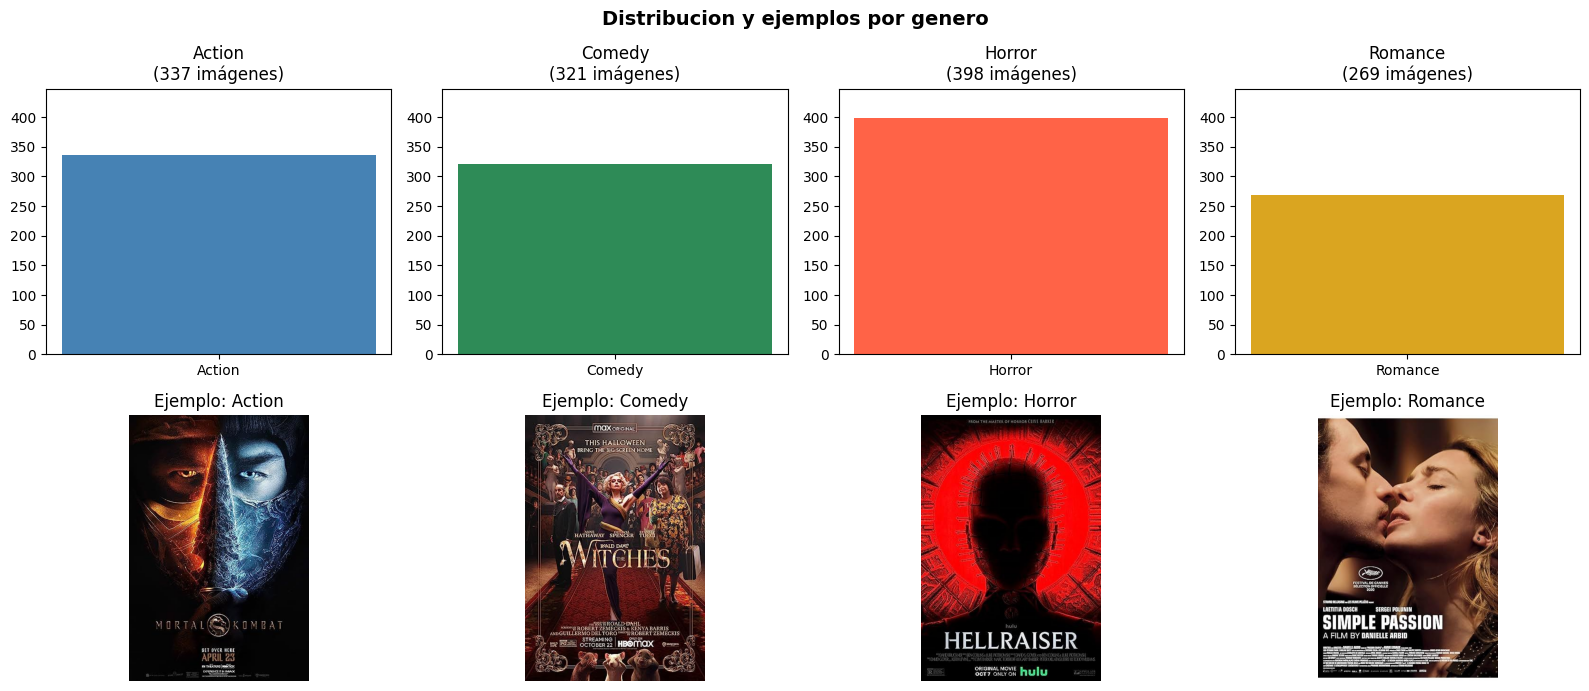

In [19]:
data_dir = Path("data/four_genre_posters/four_genre_posters")
categories = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
colors = ["steelblue", "seagreen", "tomato", "goldenrod"]

counts = {}
for cls in categories:
    cls_path = data_dir / cls
    images = sorted(cls_path.glob("*.jpg")) + sorted(cls_path.glob("*.png"))
    counts[cls] = images

for i, cls in enumerate(categories):
    images = counts[cls]
    axes[0, i].bar([cls], [len(images)], color=colors[i])
    axes[0, i].set_title(f"{cls}\n({len(images)} imágenes)")
    axes[0, i].set_ylim(0, max(len(v) for v in counts.values()) + 50)

    if images:
        img = plt.imread(images[0])
        axes[1, i].imshow(img)
        axes[1, i].set_title(f"Ejemplo: {cls}")
        axes[1, i].axis("off")

plt.suptitle("Distribucion y ejemplos por genero", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.3 Preprocesamiento

In [20]:
filepaths, labels = [], []
for cls in categories:
    cls_path = data_dir / cls
    for img in cls_path.glob("*.jpg"):
        filepaths.append(str(img))
        labels.append(cls)
    for img in cls_path.glob("*.png"):
        filepaths.append(str(img))
        labels.append(cls)

df = pd.DataFrame({"filepath": filepaths, "label": labels})
print(f"Total de imágenes: {len(df)}")
print(df["label"].value_counts())

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

print(f"Train: {len(train_df)} imágenes")
print(f"Validación: {len(val_df)} imágenes")
print(f"Test: {len(test_df)} imágenes")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
)

eval_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255.0)

def make_flow(datagen, dataframe, shuffle):
    return datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        color_mode="rgb",
        class_mode="categorical",
        classes=categories,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=42,
    )

train_gen = make_flow(train_datagen, train_df, shuffle=True)
val_gen   = make_flow(eval_datagen,  val_df,   shuffle=False)
test_gen  = make_flow(eval_datagen,  test_df,  shuffle=False)
weights = compute_class_weight(class_weight="balanced", classes=np.array(categories), y=train_df["label"].values)
class_weight = dict(zip(range(len(categories)), weights))
print("Pesos por clase:", class_weight)

Total de imágenes: 1325
label
Horror     398
Action     337
Comedy     321
Romance    269
Name: count, dtype: int64
Train: 927 imágenes
Validación: 199 imágenes
Test: 199 imágenes
Found 927 validated image filenames belonging to 4 classes.
Found 199 validated image filenames belonging to 4 classes.
Found 199 validated image filenames belonging to 4 classes.
Pesos por clase: {0: np.float64(0.9819915254237288), 1: np.float64(1.03), 2: np.float64(0.8336330935251799), 3: np.float64(1.2327127659574468)}


Las decisiones de preprocesamiento fueron tomadas considerando las características particulares del dataset de pósters de películas y los requisitos de una CNN:

* Construcción del DataFrame y división del dataset: Se creó un DataFrame con las rutas de cada imagen y su etiqueta correspondiente, inferida directamente del nombre de la carpeta que la contiene. La división se realizó en proporciones 70/15/15 para train, validación y test respectivamente, utilizando train_test_split con el parámetro stratify para garantizar que cada subconjunto mantenga la misma proporción de clases que el dataset original.

* Normalización de píxeles: Se aplicó un reescalado dividiendo cada valor de píxel entre 255.0, transformando el rango original [0, 255] al rango [0.0, 1.0]. Esta normalización acelera la convergencia del optimizador durante el entrenamiento, ya que los valores de entrada quedan en una escala uniforme y pequeña, evitando que gradientes grandes desestabilicen las actualizaciones de pesos.

* Data Augmentation en entrenamiento: Se aplicaron transformaciones aleatorias con el fin de aumentar artificialmente la diversidad de los datos y mejorar la capacidad de generalización del modelo. Las transformaciones fueron rotaciones de hasta 15°, desplazamientos horizontales y verticales de hasta el 10%, zoom de hasta el 15% y volteo horizontal. Estas transformaciones son coherentes con las variaciones naturales que pueden presentar los pósters de películas, como diferencias en encuadre o composición. 

* Tamaño de imagen y modo de color: Las imágenes fueron redimensionadas a 128×128 píxeles. Este tamaño es un balance entre conservar suficiente detalle visual de los pósters y mantener un costo computacional razonable. A diferencia del notebook de práctica que usó escala de grises, aquí se conserva el modo RGB, ya que el color es una característica discriminativa fundamental en pósters de películas. 

* Pesos de clase: Se calcularon pesos por clase utilizando compute_class_weight con la estrategia balanced, lo que asigna mayor peso a las clases con menos muestras durante el entrenamiento. Esto penaliza más los errores cometidos en clases subrepresentadas como Romance, compensando el desbalance del dataset sin necesidad de hacer re-muestreo.

### 1.4 Construcción del Modelo

In [21]:
model = Sequential([
    layers.Conv2D(32, (3, 3), padding="same", input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(4, activation="softmax"),
])

model.summary()

c:\Users\sebas\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,036 (32.36 MB)

 Trainable params: 8,483,588 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

La arquitectura CNN fue diseñada para el problema de clasificación de pósters de películas en cuatro géneros (Action, Comedy, Horror, Romance), buscando un equilibrio entre capacidad de aprendizaje y control del sobreajuste dado el tamaño reducido del dataset:

1. Bloque Conv2D(32) + BatchNormalization + ReLU + MaxPooling2D: El primer bloque convolucional aplica 32 filtros de 3×3 para detectar características de bajo nivel como bordes, contornos y gradientes de color. La BatchNormalization estabiliza las salidas normalizándolas a media cercana a cero, acelerando la convergencia. MaxPooling2D(2×2) reduce la dimensión espacial a la mitad conservando las activaciones más relevantes.

2. Bloque Conv2D(64) + BatchNormalization + ReLU + MaxPooling2D: El segundo bloque duplica los filtros a 64 para combinar las características básicas del bloque anterior y detectar patrones intermedios como formas, siluetas y agrupaciones de color propias de cada género.

3. Bloque Conv2D(128) + BatchNormalization + ReLU + MaxPooling2D: El tercer bloque con 128 filtros captura representaciones de alto nivel como composiciones visuales completas y estructuras de escena altamente discriminativas entre géneros como Horror y Romance.

4. Capa Flatten: Transforma los mapas de características tridimensionales del último bloque convolucional en un vector unidimensional, conectando la parte extractora de características con la parte clasificadora.

5. Capa Dense(256) + ReLU: Capa completamente conectada con 256 neuronas que combina las características extraídas para aprender las relaciones necesarias para distinguir entre los cuatro géneros. Se usa ReLU para introducir no linealidad y evitar el desvanecimiento del gradiente.

6. Capa Dropout(0.4): Desactiva aleatoriamente el 40% de las neuronas durante el entrenamiento, forzando a la red a aprender representaciones más robustas y reduciendo el riesgo de sobreajuste, crítico con un dataset pequeño.

7. Capa de salida Dense(4, softmax): Contiene 4 neuronas, una por género, con activación softmax que transforma las salidas en probabilidades que suman 1, permitiendo interpretar directamente la confianza del modelo en cada clase.

### 1.5 Compilación

In [22]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_checkpoint = ModelCheckpoint("model_base.keras", save_best_only=True, monitor="val_loss", mode="min")
early_stopping = EarlyStopping(monitor="val_loss", patience=10, verbose=1, mode="min")
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=5, verbose=1, mode="min")

callbacks = [model_checkpoint, early_stopping, reduce_lr]

### 1.6 Entrenamiento del primer modelo

In [23]:
if tf.config.list_physical_devices('GPU'):
    print("GPU is available. Training on GPU.")
    with tf.device('/GPU:0'):
        history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=50,
            callbacks=callbacks,
            class_weight=class_weight,
        )
else:
    print("GPU is not available. Training on CPU.")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        callbacks=callbacks,
        class_weight=class_weight,
    )

test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

GPU is not available. Training on CPU.
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 627ms/step - accuracy: 0.3474 - loss: 12.4252 - val_accuracy: 0.2462 - val_loss: 1.3523 - learning_rate: 0.0010
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - accuracy: 0.3700 - loss: 1.3324 - val_accuracy: 0.4070 - val_loss: 1.3223 - learning_rate: 0.0010
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 267ms/step - accuracy: 0.3862 - loss: 1.2992 - val_accuracy: 0.3166 - val_loss: 1.3231 - learning_rate: 0.0010
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 273ms/step - accuracy: 0.4132 - loss: 1.2748 - val_accuracy: 0.3116 - val_loss: 1.3222 - learning_rate: 0.0010
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 275ms/step - accuracy: 0.4218 - loss: 1.2788 - val_accuracy: 0.4774 - val_loss: 1.2397 - learning_rate: 0.0010
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 343ms/step - accuracy: 0.4099 - loss: 1.2669 - val_accuracy: 0.4824 - val_loss: 1.2830 - learning_rate: 0.0010
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 262ms

### 1.7 Análisis del Entrenamiento del Modelo Base

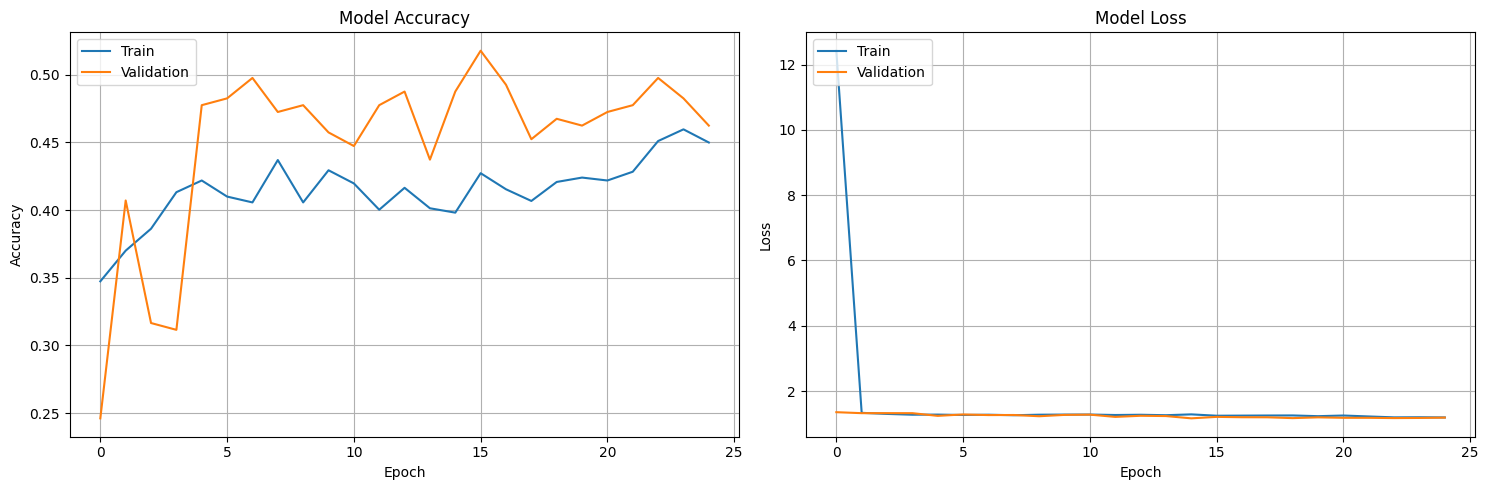

In [24]:
def plot_training_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(['Train', 'Validation'], loc='upper left')
    axs[0].grid(True)

    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['Train', 'Validation'], loc='upper left')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


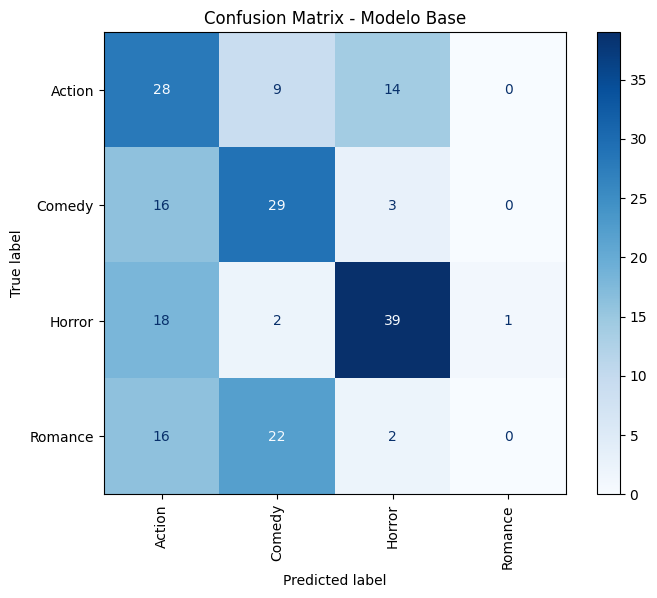

In [25]:
y_true = test_gen.classes
y_pred_probabilities = model.predict(test_gen)
y_pred = np.argmax(y_pred_probabilities, axis=1)
class_names = list(test_gen.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix - Modelo Base')
plt.show()

In [26]:
print(classification_report(y_true, y_pred, labels=range(len(class_names)), target_names=class_names, digits=4, zero_division=0))

              precision    recall  f1-score   support

      Action     0.3590    0.5490    0.4341        51
      Comedy     0.4677    0.6042    0.5273        48
      Horror     0.6724    0.6500    0.6610        60
     Romance     0.0000    0.0000    0.0000        40

    accuracy                         0.4824       199
   macro avg     0.3748    0.4508    0.4056       199
weighted avg     0.4076    0.4824    0.4377       199



* Curvas de entrenamiento: Las curvas de accuracy y loss revelan un comportamiento particular del modelo. La pérdida de entrenamiento cae drásticamente en las primeras épocas desde valores muy altos hasta estabilizarse cerca de 1.2, lo que sugiere que los pesos iniciales generaron predicciones muy poco calibradas antes de que el optimizador los corrigiera. A partir de la época 5, tanto la pérdida de entrenamiento como la de validación convergen y se mantienen estables alrededor de 1.4, sin evidencia clara de sobreajuste ya que ambas curvas siguen trayectorias similares. Sin embargo, la accuracy de entrenamiento se estanca alrededor del 40-45% mientras que la de validación oscila entre 45-52%, lo que indica que el modelo no está memorizando el conjunto de entrenamiento sino que generaliza de forma modesta pero consistente.

* Matriz de confusión: El modelo muestra un desempeño desigual entre clases. Horror es la clase mejor clasificada con 39 aciertos de 60 muestras (65%), seguida de Comedy con 29 de 48 (60.4%). Action presenta mayor confusión, siendo frecuentemente clasificada como Horror o Comedy, lo que sugiere que los pósters de acción comparten elementos visuales con ambos géneros. El caso más crítico es Romance, con 0 aciertos de 40 muestras, siendo confundida masivamente con Comedy y Action, lo que indica que el modelo no logra capturar ninguna característica visual distintiva de los pósters románticos.

* Classification Report: La precisión global del modelo es del 48.24%. El F1-score por clase confirma lo observado en la matriz: Horror (0.6610) y Comedy (0.5273) tienen el mejor desempeño, mientras que Romance obtiene un F1 de 0.0000, completamente ignorada por el modelo. El macro avg F1 de 0.4056 refleja este desequilibrio. Estos resultados son esperables para un modelo base entrenado desde cero con un dataset pequeño y establecen una línea de referencia clara para la fase de experimentación.

## 2. Experimentación y Optimización del Modelo

### 2.1 4 Bloques Convolucionales

In [42]:
model_exp1 = Sequential([
    layers.Conv2D(32, (3, 3), padding="same", input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),  # sin MaxPooling aquí
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(4, activation="softmax"),
])

model_exp1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,632,132 (32.93 MB)

 Trainable params: 8,631,428 (32.93 MB)

 Non-trainable params: 704 (2.75 KB)

In [43]:
model_exp1.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_v1 = [
    ModelCheckpoint("model_exp1_4bloques.keras", save_best_only=True, monitor="val_loss", mode="min"),
    EarlyStopping(monitor="val_loss", patience=10, verbose=1, mode="min"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=5, verbose=1, mode="min"),
]

if tf.config.list_physical_devices('GPU'):
    print("GPU is available. Training on GPU.")
    with tf.device('/GPU:0'):
        history_v1 = model_exp1.fit(
            train_gen,
            validation_data=val_gen,
            epochs=50,
            callbacks=callbacks_v1,
            class_weight=class_weight,
        )
else:
    print("GPU is not available. Training on CPU.")
    history_v1 = model_exp1.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        callbacks=callbacks_v1,
        class_weight=class_weight,
    )

test_loss_v1, test_acc_v1 = model_exp1.evaluate(test_gen)
print(f"\nTest Loss: {test_loss_v1:.4f}")
print(f"Test Accuracy: {test_acc_v1:.4f}")

GPU is not available. Training on CPU.
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 276ms/step - accuracy: 0.3333 - loss: 9.5422 - val_accuracy: 0.2864 - val_loss: 1.3938 - learning_rate: 0.0010
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 251ms/step - accuracy: 0.3916 - loss: 1.4098 - val_accuracy: 0.2060 - val_loss: 1.4844 - learning_rate: 0.0010
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - accuracy: 0.3894 - loss: 1.2883 - val_accuracy: 0.3166 - val_loss: 1.4369 - learning_rate: 0.0010
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 250ms/step - accuracy: 0.3970 - loss: 1.2855 - val_accuracy: 0.3015 - val_loss: 1.5036 - learning_rate: 0.0010
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step - accuracy: 0.4239 - loss: 1.2487 - val_accuracy: 0.3769 - val_loss: 1.3761 - learning_rate: 0.0010
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - accuracy: 0.4477 - loss: 1.2417 - val_accuracy: 0.3769 - val_loss: 1.7045 - learning_rate: 0.0010
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/s

### 2.2 Búsqueda de Hiperparámetros con Keras Tuner

In [29]:
def build_model(hp):
    model = keras.Sequential([
        layers.Conv2D(
            filters=hp.Choice('filters_1', [32, 64]),
            kernel_size=(3, 3),
            padding='same',
            activation='relu',
            input_shape=(128, 128, 3)
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(
            filters=hp.Choice('filters_2', [64, 128]),
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(
            filters=hp.Choice('filters_3', [128, 256]),
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Flatten(),

        layers.Dense(
            units=hp.Choice('dense_units', [128, 256, 512]),
            activation='relu'
        ),
        layers.Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)),

        layers.Dense(4, activation='softmax')
    ])

    lr = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [30]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=8,
    directory='tuner_dir',
    project_name='cnn_poster_tune'
)

callbacks_tuner = [
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min'),
]

tuner.search(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks_tuner,
    class_weight=class_weight
)

Trial 8 Complete [00h 01m 32s]
val_accuracy: 0.4170854389667511

Best val_accuracy So Far: 0.44723618030548096
Total elapsed time: 00h 25m 11s


In [31]:
best_model = tuner.get_best_models(1)[0]

callbacks_best = [
    ModelCheckpoint('best_model_tuner.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min'),
]

history_tuner = best_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks_best,
    class_weight=class_weight
)

test_loss_tuner, test_acc_tuner = best_model.evaluate(test_gen)
print(f"\nTest Loss: {test_loss_tuner:.4f}")
print(f"Test Accuracy: {test_acc_tuner:.4f}")

Epoch 1/50


c:\Users\sebas\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 312ms/step - accuracy: 0.4132 - loss: 1.4200 - val_accuracy: 0.3367 - val_loss: 8.3829 - learning_rate: 0.0010
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 305ms/step - accuracy: 0.4078 - loss: 1.3236 - val_accuracy: 0.2111 - val_loss: 4.9550 - learning_rate: 0.0010
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 320ms/step - accuracy: 0.4315 - loss: 1.2351 - val_accuracy: 0.2060 - val_loss: 11.3506 - learning_rate: 0.0010
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 327ms/step - accuracy: 0.4239 - loss: 1.2769 - val_accuracy: 0.3065 - val_loss: 1.5313 - learning_rate: 0.0010
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 315ms/step - accuracy: 0.4574 - loss: 1.2272 - val_accuracy: 0.3970 - val_loss: 3.8209 - learning_rate: 0.0010
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 298ms/step - accuracy: 0.4132 - loss: 1.2585 - val_accuracy: 0.2814 - val_loss: 2.2658 - learning_rate: 0.0010
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 294ms/step - accuracy: 0.4132 - loss: 1.2008 - val_accu

### 2.3 Evaluación de Resultados

In [ ]:
model = load_model('model_base.keras')
model_exp1 = load_model('model_exp1_4bloques.keras')
best_model = load_model('best_model_tuner.keras')
y_true = test_gen.classes
y_pred_base = np.argmax(model.predict(test_gen, verbose=0), axis=1)
_, acc_base = model.evaluate(test_gen, verbose=0)
y_pred_exp1 = np.argmax(model_exp1.predict(test_gen, verbose=0), axis=1)
_, acc_exp1 = model_exp1.evaluate(test_gen, verbose=0)
y_pred_tuner = np.argmax(best_model.predict(test_gen, verbose=0), axis=1)
_, acc_tuner = best_model.evaluate(test_gen, verbose=0)

modelos = ["Modelo Base", "4 Bloques Convolucionales", "Keras Tuner"]
preds = [y_pred_base, y_pred_exp1, y_pred_tuner]
accs = [acc_base, acc_exp1, acc_tuner]

rows = []
for nombre, y_pred, acc in zip(modelos, preds, accs):
    rows.append({
        "Modelo":    nombre,
        "Accuracy":  round(acc, 4),
        "Precision": round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        "F1 Macro":  round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
    })

df_resultados = pd.DataFrame(rows)
print(df_resultados.to_string(index=False))

                   Modelo  Accuracy  Precision  Recall  F1 Macro
              Modelo Base    0.4874     0.3572  0.4464    0.3959
4 Bloques Convolucionales    0.4824     0.4938  0.4508    0.4384
              Keras Tuner    0.5477     0.5668  0.5333    0.5287


### 2.4 Visualización

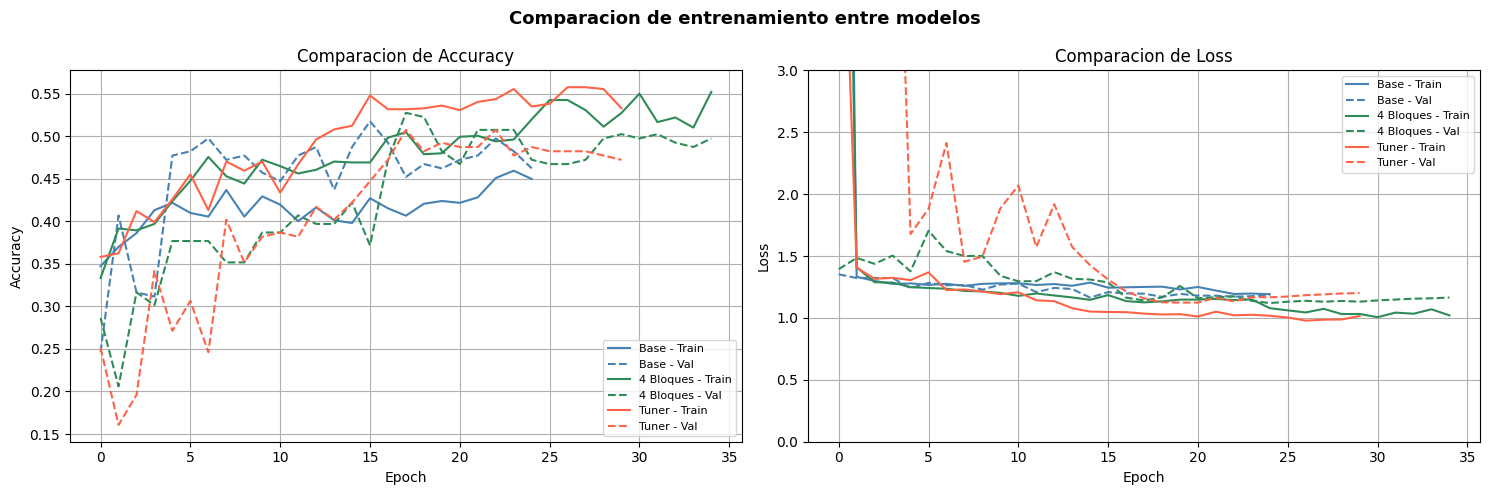

In [58]:
import json

with open('history_base.json', 'r') as f:
    hist_base = json.load(f)
with open('history_exp1.json', 'r') as f:
    hist_exp1 = json.load(f)
with open('history_tuner.json', 'r') as f:
    hist_tuner = json.load(f)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(hist_base['accuracy'], label='Base - Train',  color='steelblue')
axs[0].plot(hist_base['val_accuracy'], label='Base - Val',    color='steelblue', linestyle='--')
axs[0].plot(hist_exp1['accuracy'], label='4 Bloques - Train',  color='seagreen')
axs[0].plot(hist_exp1['val_accuracy'],label='4 Bloques - Val',    color='seagreen',  linestyle='--')
axs[0].plot(hist_tuner['accuracy'], label='Tuner - Train', color='tomato')
axs[0].plot(hist_tuner['val_accuracy'],label='Tuner - Val',   color='tomato',    linestyle='--')
axs[0].set_title('Comparacion de Accuracy')
axs[0].set_ylabel('Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].legend(loc='lower right', fontsize=8)
axs[0].grid(True)

axs[1].plot(hist_base['loss'], label='Base - Train',  color='steelblue')
axs[1].plot(hist_base['val_loss'], label='Base - Val',    color='steelblue', linestyle='--')
axs[1].plot(hist_exp1['loss'],label='4 Bloques - Train',  color='seagreen')
axs[1].plot(hist_exp1['val_loss'], label='4 Bloques - Val',    color='seagreen',  linestyle='--')
axs[1].plot(hist_tuner['loss'], label='Tuner - Train', color='tomato')
axs[1].plot(hist_tuner['val_loss'], label='Tuner - Val',   color='tomato',    linestyle='--')
axs[1].set_title('Comparacion de Loss')
axs[1].set_ylabel('Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylim(0, 3)
axs[1].legend(loc='upper right', fontsize=8)
axs[1].grid(True)

plt.suptitle('Comparacion de entrenamiento entre modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

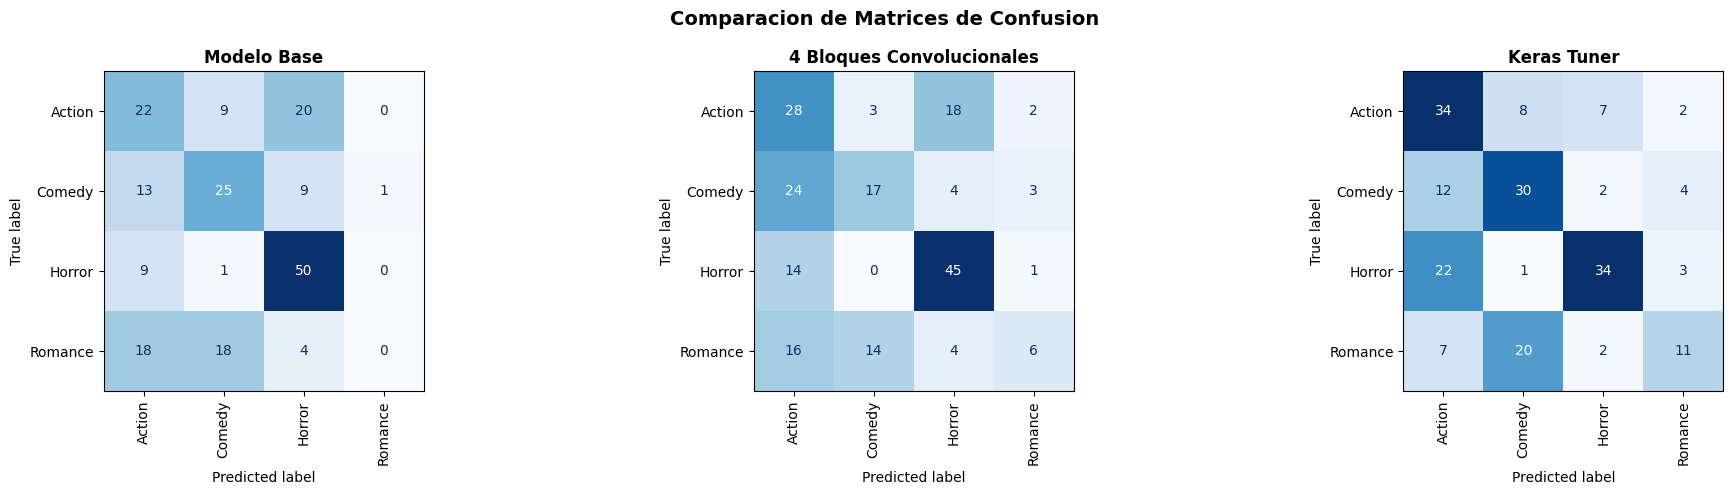

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, cm_pred, titulo in zip(
    axes,
    [y_pred_base, y_pred_exp1, y_pred_tuner],
    ["Modelo Base", "4 Bloques Convolucionales", "Keras Tuner"]
):
    cm = confusion_matrix(y_true, cm_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical', colorbar=False)
    ax.set_title(titulo, fontsize=12, fontweight='bold')

plt.suptitle("Comparacion de Matrices de Confusion", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Análisis y Discusión de Resultados

## 3.1 Comparación de Experimentos

Los tres modelos entrenados muestran una evolución clara en su desempeño. El modelo base alcanzó una accuracy de 48.74% con un F1 macro de 0.3959, estableciendo un primer punto de comparación. El experimento de 4 bloques convolucionales obtuvo una accuracy similar de 48.24%, pero con una mejora notable en precisión (0.4938) y F1 macro (0.4384). Lo que indica que "aunque no clasificó mas imagenes correctamente en total, logra distingir mejor entre las clases. Finalmente, el mejor optimizado con Keras Tuner superó a ambos con una accuracy de 54.77% y un F1 macro de 0.5287, mostrando que una búsqueda sistemática de hiperparámetros puede ser más efectiva que ajustar manualmente.


#### ¿Qué impacto tiene la profundidad de la red y el número de filtros en la capacidad de aprendizaje?

Al aumentar la profundidad de la red, esta mejoró la capacidad de extracción de características, especialmente para clases con patrones visuales complejos. Sin embargo, existe un límite determinado por el tamaño del dataset, con la cantidad de imágenes actuales las redes muy profundas tienden a sobreajustarse o a no converger adecuadamente. En este sentido, el modelo de 4 bloques mostró que mantener 128 filtros en el bloque adicional, en lugar de aumentarlos, ayuda a controlar ese sobreajuste.

#### ¿Cómo influyen las técnicas de regularización (por ejemplo, Dropout) en la capacidad de generalización del modelo?

El Dropout demostró ser relevante para el rendimiento del modelo con un dataset pequeños. Si una tasa es muy alta impide completamente el aprendizaje, mientras que una tasa muy baja podría generar sobreajuste. El Keras Tuner encontró que Dropout de 0.2 con Dense de 128 neuronas era la configuración óptima. Lo que indica que reducir la capacidad de la red puede ser más efectivo que aumentar la regularización para este tamaño de dataset.

#### ¿Qué mejoras adicionales se podrían implementar para optimizar aún más el rendimiento del modelo?

Una de las mejoras importantes es el uso de transfer learning con modelos preentrenados como VGG16, ResNet o EfficientNet que permitirían aprovechar características aprendidas en millones de imágenes, lo que es util con datasets pequeños. También se podrían implementar técnicas de data augmentation más agresivas como CutMix o MixUp para aumentar artificialmente la diversidad del dataset. Ademas, recolectar más imágenes de las clases subrepresentadas, especialmente Romance, reduciría el desbalance y mejoraría la clasificación de clases difíciles. Finalmente, realizar una búsqueda de hiperparámetros más amplia (con más pruebas y épocas) podría llevar a encontrar configuraciones aún mejores.

## 3.2 Conclusiones

En general, este taller permitió comparar distintas configuraciones de redes convolucionales para clasificar pósters de películas. El modelo base sirvió como referencia, el modelo más profundo mejoró la capacidad de diferenciación entre clases, y el Keras Tuner demostró ser la estrategia más efectiva al lograr el mejor rendimiento con una arquitectura más liviana. Un patrón consistente en todos los modelos fue la dificultad para clasificar Romance, género que comparte elementos visuales con los demás y que además cuenta con menos muestras en el dataset.

Como trabajo futuro, una de las mejoras más prometedoras es implementar transfer learning con modelos como EfficientNet o MobileNet, especialmente útiles cuando se cuenta con pocos datos. A esto se le puede sumar la ampliación del dataset, sobre todo en clases subrepresentadas, y el uso de técnicas de augmentation más avanzadas como CutMix o MixUp. Estas estrategias ayudarían a reducir el desbalance y mejorar el desempeño general del modelo, en particular en las clases más difíciles.